**ANN - Classifier - Binary**

**Import required libraries**

In [1]:
# Import libraries
import keras 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np 
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split

In [2]:
# Reading data 
data = pd.read_csv('C:/MAFAS/APU/CT046-3-M-AML/CT046 - LABS/Python LAB MATERIALS/Lab 9 - Neural Network/diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Outcome
0    500
1    268
Name: count, dtype: int64


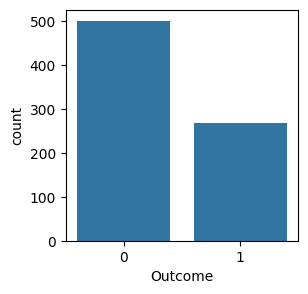

In [3]:
print(data["Outcome"].value_counts())
plt.figure(figsize = (3,3))
sns.countplot(x = 'Outcome', data = data)
plt.show()

**Setting IV & TV**

In [4]:
x = data.drop(columns = 'Outcome', axis = 1)
y = data['Outcome']

**Data Split**

In [5]:
# Data Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

**Class Balancing**

In [6]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x_train, y_train = smote.fit_resample(x_train, y_train)

**Normalization**

In [7]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

### Neural network module

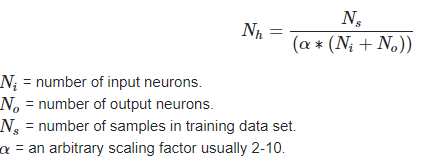

In [8]:
from keras.models import Sequential 
from keras.layers import Input, Dense, Dropout 

In [9]:
classifier = Sequential()

# IL
# The number of neurons is equal to the number of IV in your data.
classifier.add(Input(shape = (8,)))

# HL 1
classifier.add(Dense(units = 256, kernel_initializer = 'uniform', activation = 'relu'))
classifier.add(Dropout(0.2))

# HL 2
classifier.add(Dense(units = 128, kernel_initializer = 'uniform', activation = 'relu'))
classifier.add(Dropout(0.2))

# OL
# If the NN is a classifier, then single node unless softmax is used in which case the OL has one node per class label in your model.
classifier.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid')) # Sigmoid due to binary classification
classifier.add(Dropout(0.2))

# Compiling Neural Network
classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,329 (138.00 KB)

 Trainable params: 35,329 (138.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Fitting the model 
history = classifier.fit(x_train, y_train, validation_split = 0.1, batch_size = 16, epochs = 100)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5332 - loss: 1.6406 - val_accuracy: 0.5556 - val_loss: 0.8468
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7140 - loss: 2.2309 - val_accuracy: 0.5926 - val_loss: 0.7821
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7458 - loss: 1.6919 - val_accuracy: 0.4074 - val_loss: 0.9267
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7406 - loss: 1.7147 - val_accuracy: 0.6543 - val_loss: 0.6537
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7430 - loss: 1.9844 - val_accuracy: 0.6914 - val_loss: 0.6450
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7247 - loss: 1.9976 - val_accuracy: 0.5679 - val_loss: 0.7958
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7635 - loss: 1.6300 - val_accuracy: 0.6296 - val_loss: 0.7162
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7302 - loss: 1.7319 - val_accuracy: 0.6420 - v

In [11]:
# Predicting the Test set results
y_pred = classifier.predict(x_test)
y_pred = (y_pred > 0.5)
y_pred

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


array([[False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [

**Model Evaluation**

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix: \n", confusion_matrix(y_test, y_pred))
print("\nclassification_report: \n", classification_report(y_test, y_pred))

Accuracy:  0.7467532467532467

Confusion Matrix: 
 [[82 17]
 [22 33]]

classification_report: 
               precision    recall  f1-score   support

           0       0.79      0.83      0.81        99
           1       0.66      0.60      0.63        55

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



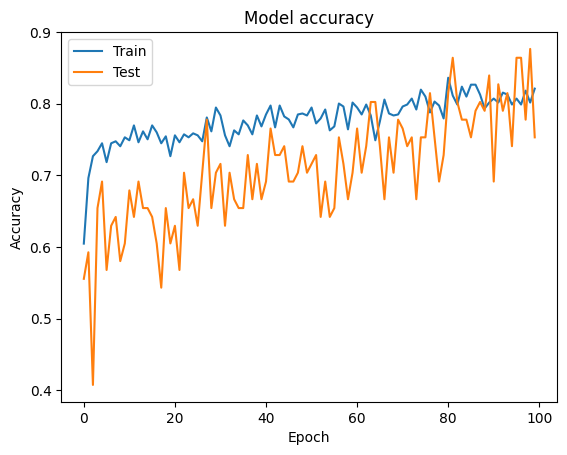

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

**ANN with Callbacks**

In [14]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import ModelCheckpoint

In [15]:
classifier = Sequential()

# IL
# The number of neurons is equal to the number of IV in your data.
classifier.add(Input(shape = (8,)))

# HL 1
classifier.add(Dense(units = 256, kernel_initializer = 'uniform', activation = 'relu'))
classifier.add(Dropout(0.2))

# HL 2
classifier.add(Dense(units = 128, kernel_initializer = 'uniform', activation = 'relu'))
classifier.add(Dropout(0.2))

# OL
# If the NN is a classifier, then single node unless softmax is used in which case the OL has one node per class label in your model.
classifier.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid')) # Sigmoid due to binary classification
classifier.add(Dropout(0.2))

# Compiling Neural Network
classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

classifier.summary()

# model checkpoint
file = 'Best_DNN_Model.keras'
checkpoint = ModelCheckpoint (file, monitor = 'val_accuracy', verbose = 1, save_best_only = True, mode = 'max')
callbacks_list = [checkpoint]


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,329 (138.00 KB)

 Trainable params: 35,329 (138.00 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = classifier.fit(x_train, y_train, validation_split = 0.1, batch_size = 16, epochs = 100, callbacks = callbacks_list)

Epoch 1/100
29/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5090 - loss: 2.1734
Epoch 1: val_accuracy improved from -inf to 0.48148, saving model to Best_DNN_Model.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5283 - loss: 2.1253 - val_accuracy: 0.4815 - val_loss: 0.8851
Epoch 2/100
36/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7097 - loss: 1.9393 
Epoch 2: val_accuracy improved from 0.48148 to 0.60494, saving model to Best_DNN_Model.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7073 - loss: 1.9726 - val_accuracy: 0.6049 - val_loss: 0.7478
Epoch 3/100
38/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7348 - loss: 1.7502 
Epoch 3: val_accuracy did not improve from 0.60494
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7314 - loss: 1.7890 - val_accuracy: 0.5432 - val_loss: 0.8148
Epoch 4/100
26/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7087 - loss: 1.9857 
Epoch 4: val_accuracy did not improve from 0.60494
46/46 ━━━━━━━━━━━━━━━━━━━━ 

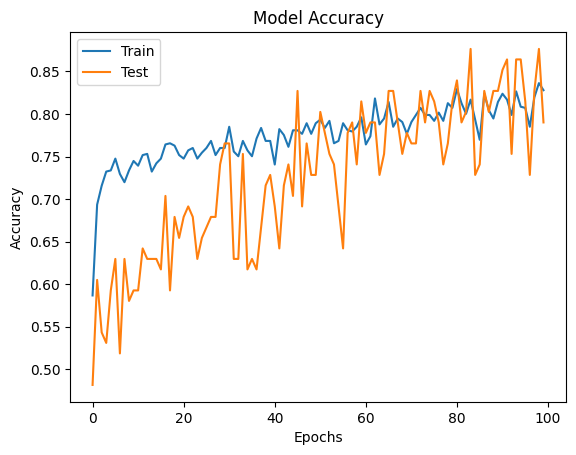

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'], loc = 'upper left')
plt.show()

In [18]:
classifier.load_weights('Best_DNN_Model.keras')
y_pred = classifier.predict(x_test)
y_pred = (y_pred > 0.5)
y_pred

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


array([[ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [

In [19]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

[[72 27]
 [19 36]]

              precision    recall  f1-score   support

           0       0.79      0.73      0.76        99
           1       0.57      0.65      0.61        55

    accuracy                           0.70       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.71      0.70      0.71       154



**Tuning using Keras Tuner**

A faster technique from Keras

In [20]:
# %pip install keras-tuner

In [21]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow import keras

In [22]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

def build_model(hp):
    model = Sequential()
    
    hp_units_1 = hp.Int('HL1', min_value = 128, max_value = 512, step = 2)
    model.add(Dense(units = hp_units_1, kernel_initializer = 'uniform', activation = 'relu'))

    hp_units_2 = hp.Int('HL2', min_value = 128, max_value = 512, step = 2)
    model.add(Dense(units = hp_units_2, kernel_initializer = 'uniform', activation = 'relu'))
    
    hp_dropout_1 = hp.Float('DO1', min_value = 0.1, max_value = 0.5, step = 0.1)
    model.add(Dropout(hp_dropout_1))
    
    hp_dropout_2 = hp.Float('DO2', min_value = 0.1, max_value = 0.5, step = 0.1)
    model.add(Dropout(hp_dropout_2))
    
    model.add(Dense(1, activation = 'sigmoid'))

    hp_batch = hp.Choice('Batch Size', [8, 16, 32, 64, 128])
    hp_optimizers = hp.Choice('Optimizer', ['sgd', 'adam', 'rmsprop'])

    model.compile(optimizer = hp_optimizers, loss = 'binary_crossentropy', metrics = ['accuracy'])
    return model

tuner = kt.GridSearch(build_model, objective = 'val_accuracy', max_trials = 5, overwrite = True)

hp_batch = tuner.oracle.get_space().get('Batch Size')

tuner.search(x_train, y_train, validation_split = 0.1, epochs = 100)

Trial 5 Complete [00h 00m 16s]
val_accuracy: 0.9753086566925049

Best val_accuracy So Far: 0.9876543283462524
Total elapsed time: 00h 01m 26s


In [23]:
for h_param in [f"HL1" for i in range(1)] + [f"HL2" for i in range(1)] + [f"DO1" for i in range(1)] + [f"DO2" for i in range(1)] + ['Batch Size'] + ['Optimizer']:
    print(h_param, tuner.get_best_hyperparameters()[0].get(h_param))

HL1 128
HL2 128
DO1 0.1
DO2 0.1
Batch Size 8
Optimizer adam


In [24]:
tuner.results_summary(num_trials=10)

Results summary
Results in .\untitled_project
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 1 summary
Hyperparameters:
HL1: 128
HL2: 128
DO1: 0.1
DO2: 0.1
Batch Size: 8
Optimizer: adam
Score: 0.9876543283462524

Trial 2 summary
Hyperparameters:
HL1: 128
HL2: 128
DO1: 0.1
DO2: 0.1
Batch Size: 8
Optimizer: rmsprop
Score: 0.9876543283462524

Trial 4 summary
Hyperparameters:
HL1: 128
HL2: 128
DO1: 0.1
DO2: 0.1
Batch Size: 16
Optimizer: adam
Score: 0.9753086566925049

Trial 3 summary
Hyperparameters:
HL1: 128
HL2: 128
DO1: 0.1
DO2: 0.1
Batch Size: 16
Optimizer: sgd
Score: 0.7407407164573669

Trial 0 summary
Hyperparameters:
HL1: 128
HL2: 128
DO1: 0.1
DO2: 0.1
Batch Size: 8
Optimizer: sgd
Score: 0.7283950448036194


In [25]:
best_model = tuner.get_best_models(num_models=1)[0]

c:\Users\raheem\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [26]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,793 (69.50 KB)

 Trainable params: 17,793 (69.50 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
y_pred = best_model.predict(x_test)
y_pred = (y_pred > 0.5)
y_pred

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001DA9B525620> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


array([[ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [

In [28]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

[[65 34]
 [15 40]]

              precision    recall  f1-score   support

           0       0.81      0.66      0.73        99
           1       0.54      0.73      0.62        55

    accuracy                           0.68       154
   macro avg       0.68      0.69      0.67       154
weighted avg       0.72      0.68      0.69       154

